In [1]:
!pip install upsetplot

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24866 sha256=73f3220e9a0f88c34b88892b481dcf1f72cc334a502f43223a1668b0cdc25c87
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a28191fa373d81292fcf73a4ddb8
Successfully built upsetplot


In [2]:
!pip install numpy pandas matplotlib scikit-learn

In [3]:
camembert_file  = "tous_entites_nommes_Camembert.json"
stanza_file = "tous_entites_nommes_Stanza.json"
spacy_lg_file = "tous_entites_nommes_Spacy_lg.json"
spacy_sm_file = "tous_entites_nommes_Spacy_sm.json"
#flaubert_file = "tous_entites_nommes_Flaubert_0428.json"

Lecture de Camembert ...
Lecture de Stanza ...
Lecture de Spacy_lg ...
Lecture de Spacy_sm ...

Modèles inclus : ['Camembert', 'Stanza', 'Spacy_lg', 'Spacy_sm']


/usr/local/lib/python3.12/dist-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/

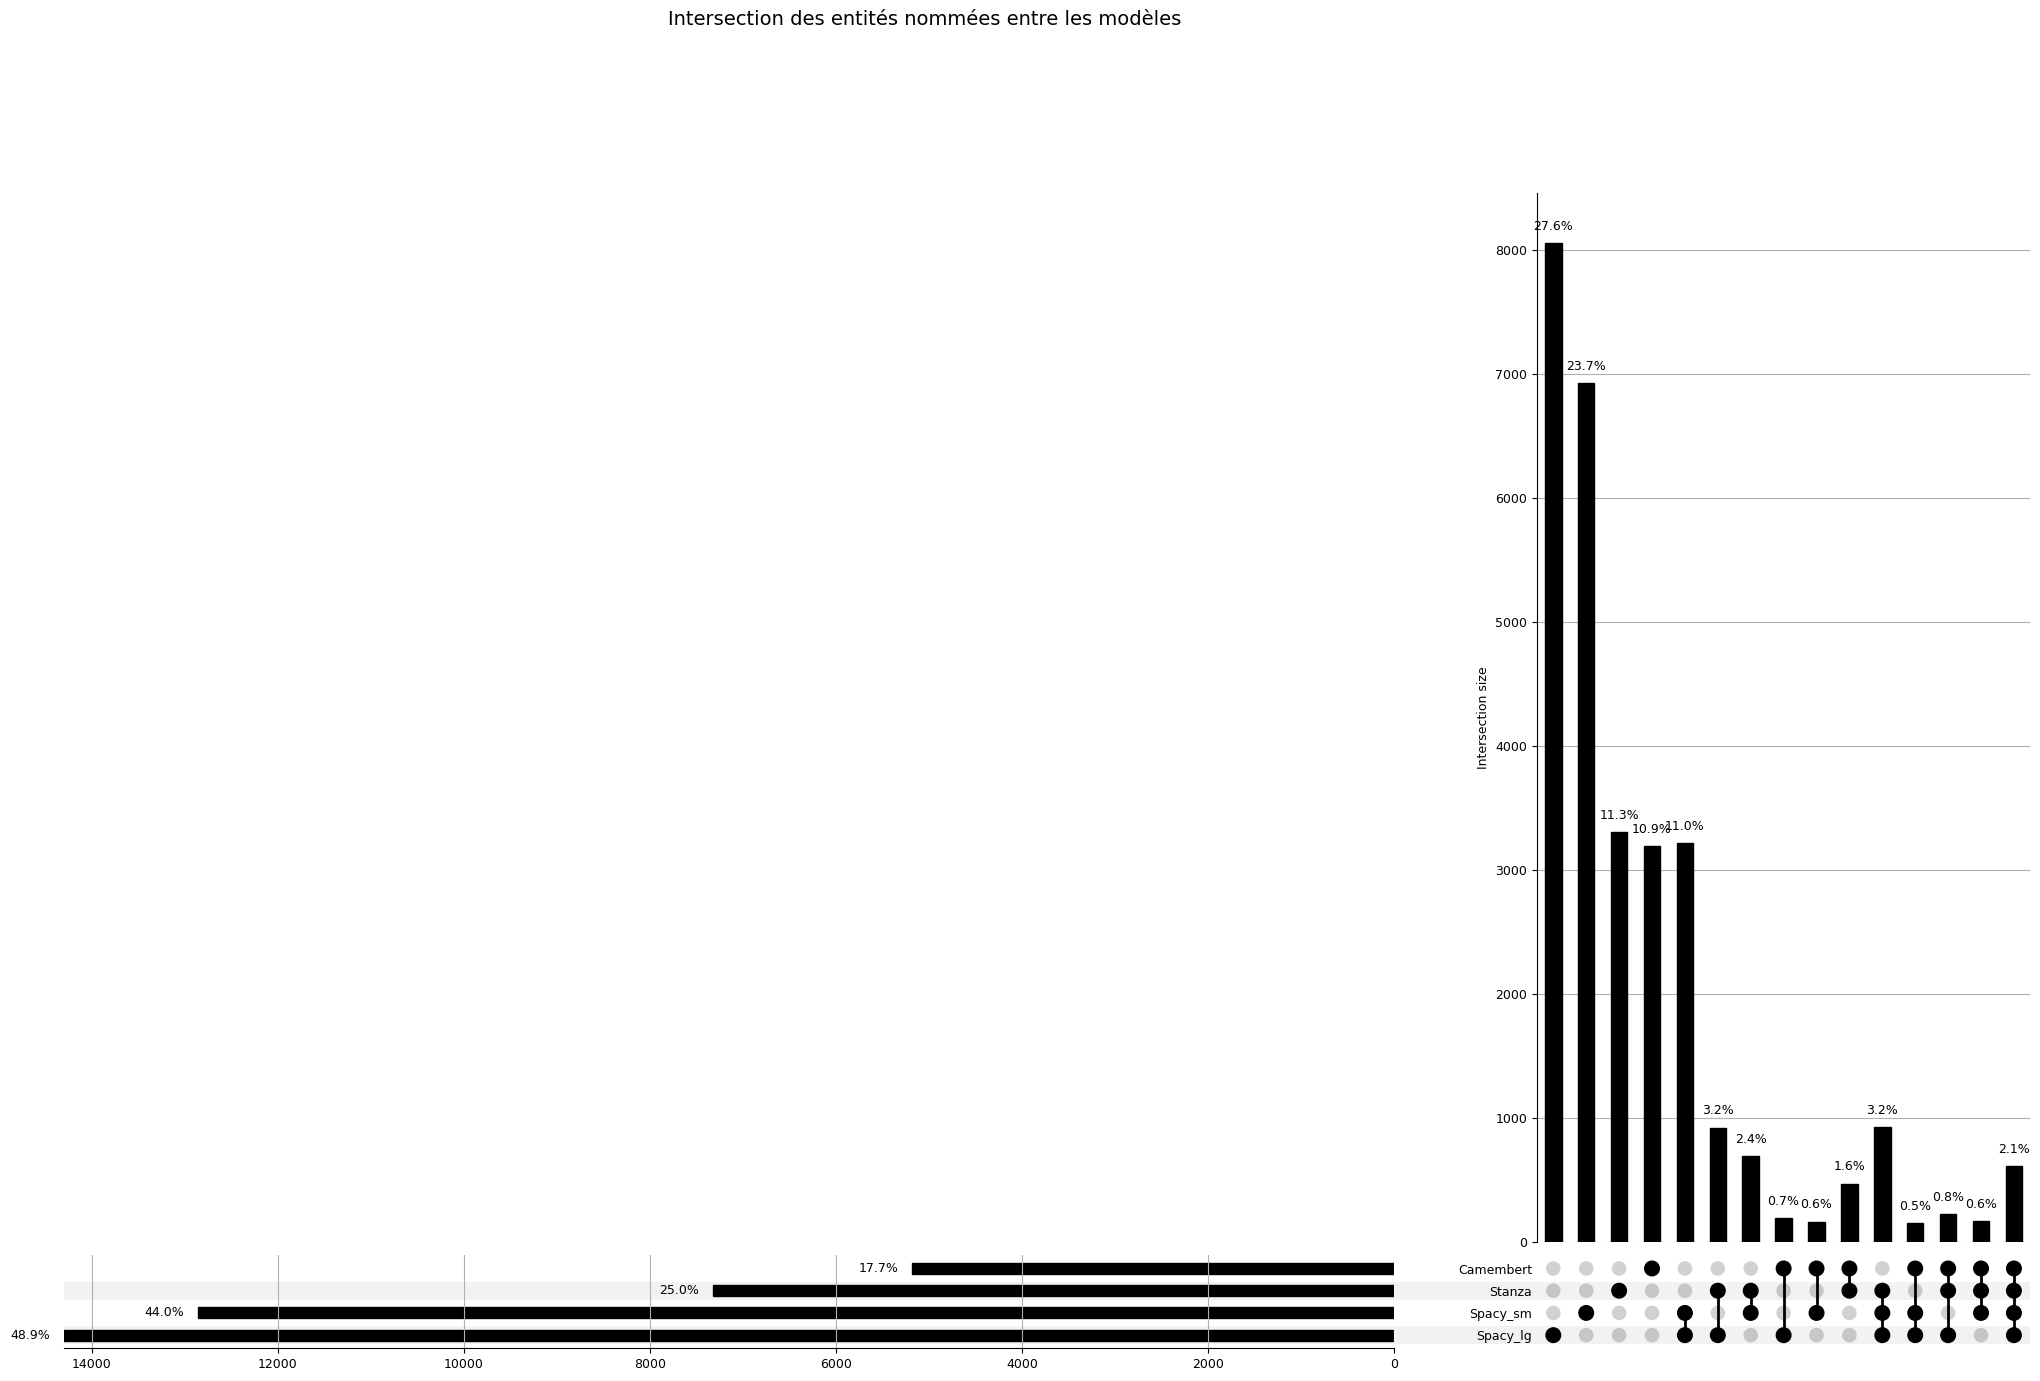


Exemples d'entités reconnues par les 4 modèles :
Paolo (PER)
Prado (LOC)
Seigneur (MISC)
Reptile (PER)
Saint-Merry (LOC)
Athènes (LOC)
Perse (LOC)
Montaigne (PER)
Perséphoné (PER)
Euclide (PER)
Arthur Rimbaud (PER)
Ormeaux (LOC)
La Mort (MISC)
Montlignon (LOC)
Ophélie (PER)
Norwège (LOC)
Jean Jaurès (PER)
Newton (PER)
Bavant (PER)
Rome (LOC)
Vénus (LOC)
Schubert (PER)
Calligrammes (MISC)
L'Odeur des Vignes (MISC)
P. de Barante (PER)
Néréide (PER)
Thèbes (LOC)
palais des Doges (LOC)
Récits (MISC)
César (PER)
Aède de Lesbôs (PER)
Rollin (PER)
Savonarole (PER)
Roller (PER)
Cromwell (PER)
Pan (PER)
sac de Rome (MISC)
Philis (PER)
Guernesey (LOC)
Sévigné (PER)
Mêle (PER)
Styx (PER)
Mirabeau (PER)
Calvin (PER)
Norvège (LOC)
Champs-Elysées (LOC)
Messine (LOC)
Sylla (PER)
Ardennes (LOC)
Saint Jean (PER)
Veillez (MISC)
Gurinnô (PER)
Rimbaud (PER)
Hésiode (PER)
Je me souviens (MISC)
Arioste (PER)
Adonis (PER)
Caton (PER)
Hermann (PER)
Midi (LOC)
Caïn (PER)
Hercule (PER)
Sténio (PER)
Me (MISC)
c

In [7]:
import json
import re
from matplotlib import pyplot as plt
from upsetplot import from_contents, UpSet

# === Fonction générale pour lire automatiquement les entités nommées (texte + label) ===
def lire_entites_unifiees(chemin):
    with open(chemin, encoding='utf-8') as f:
        contenu = f.read()

    entites_extraites = []

    try:
        data = json.loads(contenu)

        #  Cas Camembert / Stanza
        if "entites" in data:
            entites_extraites = [
                (e.get("mot") or e.get("texte"),
                 e.get("label") or e.get("type") or e.get("categorie") or "")
                for e in data["entites"]
                if ("mot" in e or "texte" in e)
            ]

        # Cas SpaCy / Flaubert (plusieurs documents)
        elif isinstance(data, dict):
            for doc_data in data.values():
                entite_liste = (
                    doc_data.get("entités nommées")
                    or doc_data.get("entités")
                    or []
                )
                for e in entite_liste:
                    texte = e.get("mot") or e.get("texte")
                    label = e.get("label") or e.get("type") or e.get("categorie") or ""
                    if texte:
                        entites_extraites.append((texte, label))

    except json.JSONDecodeError:
        # Cas où plusieurs objets JSON sont concaténés
        blocs = re.findall(r'\{.*?\}', contenu, re.DOTALL)
        for bloc in blocs:
            try:
                obj = json.loads(bloc)
                if "entites" in obj:
                    entites_extraites.extend([
                        (e.get("mot") or e.get("texte"),
                         e.get("label") or e.get("type") or e.get("categorie") or "")
                        for e in obj["entites"]
                        if ("mot" in e or "texte" in e)
                    ])
            except Exception:
                continue

    return set(entites_extraites)


# === Dictionnaire des fichiers : associer chaque modèle à son fichier JSON ===
file_model_map = {
    "Camembert": "tous_entites_nommes_Camembert.json",
    "Stanza": "tous_entites_nommes_Stanza.json",
    "Spacy_lg": "tous_entites_nommes_Spacy_lg.json",
    "Spacy_sm": "tous_entites_nommes_Spacy_sm.json",
    # "Flaubert": "tous_entites_nommes_Flaubert.json"
}

# === Lecture des entités nommées pour tous les modèles ===
dico_fusionne = {}
for modele, chemin in file_model_map.items():
    print(f"Lecture de {modele} ...")
    dico_fusionne[modele] = lire_entites_unifiees(chemin)

print("\nModèles inclus :", list(dico_fusionne.keys()))

# === Visualisation UpSetPlot ===
test = from_contents(dico_fusionne)

upset = UpSet(
    test,
    orientation='horizontal',
    sort_by='degree',
    show_percentages=True,
    totals_plot_elements=40,
    intersection_plot_elements=40,
    element_size=30
)

fig = plt.figure(figsize=(30, 15))
plt.subplots_adjust(left=0.15, right=0.95, top=0.88, bottom=0.25, wspace=0.35, hspace=0.25)
upset.plot(fig=fig)

for text in fig.findobj(plt.Text):
    text.set_fontsize(9)

plt.suptitle("Intersection des entités nommées entre les modèles", fontsize=14)
plt.savefig("upsetplot_all_models_adjusted.png", dpi=300)
plt.show()

# === Partie 2 : Exemples concrets avec labels ===
def afficher_exemples(titre, ensemble, n=100):
    print(f"\n{titre}")
    for mot, label in list(ensemble)[:n]:
        print(f"{mot} ({label})")

# 交集：同时被所有模型识别的实体
communes_4 = set.intersection(*dico_fusionne.values())
afficher_exemples("Exemples d'entités reconnues par les 4 modèles :", communes_4)

# 仅 spaCy_lg 识别的实体
uniques_spacy_lg = dico_fusionne["Spacy_lg"] - (
    dico_fusionne["Spacy_sm"] | dico_fusionne["Stanza"] | dico_fusionne["Camembert"]
)
afficher_exemples("Exemples d'entités uniques à spaCy_lg :", uniques_spacy_lg)

# 仅 spaCy_sm 识别的实体
uniques_spacy_sm = dico_fusionne["Spacy_sm"] - (
    dico_fusionne["Spacy_lg"] | dico_fusionne["Stanza"] | dico_fusionne["Camembert"]
)
afficher_exemples("Exemples d'entités uniques à spaCy_sm :", uniques_spacy_sm)

# 仅 Stanza 识别的实体
uniques_stanza = dico_fusionne["Stanza"] - (
    dico_fusionne["Spacy_lg"] | dico_fusionne["Spacy_sm"] | dico_fusionne["Camembert"]
)
afficher_exemples("Exemples d'entités uniques à Stanza :", uniques_stanza)

# 仅 Camembert 识别的实体
uniques_camembert = dico_fusionne["Camembert"] - (
    dico_fusionne["Spacy_lg"] | dico_fusionne["Spacy_sm"] | dico_fusionne["Stanza"]
)
afficher_exemples("Exemples d'entités uniques à Camembert :", uniques_camembert)

# 交集：仅 spaCy_lg 和 spaCy_sm
intersection_spacy = (
    dico_fusionne["Spacy_lg"] & dico_fusionne["Spacy_sm"]
) - (dico_fusionne["Stanza"] | dico_fusionne["Camembert"])
afficher_exemples("Exemples d'entités reconnues uniquement par spaCy_lg et spaCy_sm :", intersection_spacy)

# 交集：三个模型 spaCy_lg + spaCy_sm + Stanza
intersection_3_stanza = (
    dico_fusionne["Spacy_lg"] & dico_fusionne["Spacy_sm"] & dico_fusionne["Stanza"]
) - dico_fusionne["Camembert"]
afficher_exemples("Exemples d'entités reconnues uniquement par spaCy_lg + spaCy_sm + Stanza :", intersection_3_stanza)

# 交集：三个模型 spaCy_lg + spaCy_sm + Camembert
intersection_3_camembert = (
    dico_fusionne["Spacy_lg"] & dico_fusionne["Spacy_sm"] & dico_fusionne["Camembert"]
) - dico_fusionne["Stanza"]
afficher_exemples("Exemples d'entités reconnues uniquement par spaCy_lg + spaCy_sm + Camembert :", intersection_3_camembert)


Lecture des entités nommées extraites par chaque modèle...
🔧 Construction de la matrice binaire modèle × entité...
Préparation des paramètres pour le diagramme de Venn...
Génération du diagramme de Venn...


/content/venn_custom.py:222: RuntimeWarning: Maximum number of iterations has been exceeded.
  res = minimize(lambda p: lossFunction(p, radii, disjointOverlaps), centers, method='Nelder-Mead', options={'maxiter': 100, 'disp': True})


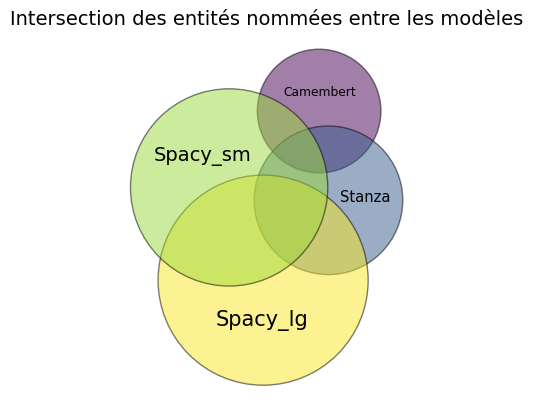

Diagramme sauvegardé sous le nom : venn_ner_models.png


In [ ]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
#from venn import df2areas, venn  #Import du module personnalisé pour Venn
from venn_custom import df2areas, venn


# === Fonction pour lire automatiquement les entités nommées à partir d’un fichier JSON ===
def lire_entites_unifiees(chemin):
    import json, re

    with open(chemin, encoding='utf-8') as f:
        contenu = f.read()

    entites_extraites = []

    try:
        data = json.loads(contenu)

        if "entites" in data:  # Format Camembert / Stanza
            entites_extraites = [e["mot"] for e in data["entites"] if "mot" in e]

        elif isinstance(data, dict):  # Format SpaCy / Flaubert (plusieurs documents)
            for doc_data in data.values():
                # ➤ Gestion des deux clés possibles : "entités" ou "entités nommées"
                entite_liste = (
                    doc_data.get("entités nommées")
                    or doc_data.get("entités")
                    or []
                )
                entites_extraites.extend(
                    [e.get("texte") for e in entite_liste if "texte" in e]
                )

    except json.JSONDecodeError:
        # Cas de fichiers JSON concaténés (non standard)
        blocs = re.findall(r'\{.*?\}', contenu, re.DOTALL)
        for bloc in blocs:
            try:
                obj = json.loads(bloc)
                if "entites" in obj:
                    entites_extraites.extend([e["mot"] for e in obj["entites"] if "mot" in e])
            except Exception:
                continue

    return set(entites_extraites)


# === Dictionnaire associant les modèles aux fichiers JSON correspondants ===
file_model_map = {
    "Camembert": "tous_entites_nommes_Camembert.json",
    "Stanza": "tous_entites_nommes_Stanza.json",
    "Spacy_lg": "tous_entites_nommes_Spacy_lg.json",
    "Spacy_sm": "tous_entites_nommes_Spacy_sm.json",
    #"Flaubert": "sample_data/tous_entites_nommes_Flaubert_0428.json"
}


# === Programme principal ===
def main():
    print("Lecture des entités nommées extraites par chaque modèle...")
    model_entities = {name: lire_entites_unifiees(path) for name, path in file_model_map.items()}

    all_entities = set.union(*model_entities.values())

    print("🔧 Construction de la matrice binaire modèle × entité...")
    data = defaultdict(dict)
    for entity in all_entities:
        for model, ents in model_entities.items():
            data[entity][model] = int(entity in ents)

    df = pd.DataFrame.from_dict(data, orient='index')

    print("Préparation des paramètres pour le diagramme de Venn...")
    labels, radii, actualOverlaps, disjointOverlaps = df2areas(df, fineTune=True)

    print("Génération du diagramme de Venn...")
    fig, ax = venn(
        radii,
        actualOverlaps,
        disjointOverlaps,
        labels=labels,
        labelsize='auto',
        cmap=None,
        fineTune=True
    )
    plt.title("Intersection des entités nommées entre les modèles", fontsize=14)
    plt.savefig("venn_ner_models.png", dpi=300, transparent=True)
    plt.show()
    print("Diagramme sauvegardé sous le nom : venn_ner_models.png")


if __name__ == "__main__":
    main()
